In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Project environment is ready!")
print("Python:", sys.version)
print("Environment:", sys.executable)

Project environment is ready!
Python: 3.13.15 | packaged by Anaconda, Inc. | (main, Aug 14 2026, 17:17:48) [MSC v.1942 64 bit (AMD64)]
Environment: C:\Users\delll\anaconda3\envs\smartroute\python.exe


In [ ]:
%pip install nltk wordcloud shap evidently streamlit plotly joblib

In [4]:
import sys
!{sys.executable} -m pip install --upgrade pip setuptools wheel

In [1]:
import shap

print("SHAP installed successfully!")
print("SHAP version:", shap.__version__)

SHAP installed successfully!
SHAP version: 0.52.0


In [8]:
import pandas as pd
import numpy as np
import sklearn
import nltk
import shap
import evidently
import streamlit
import plotly
import joblib
import wordcloud

print("All project packages are installed successfully!")

All project packages are installed successfully!


In [7]:
import shap
import evidently
import streamlit
import plotly
import joblib
import wordcloud
import nltk

print("All required packages are installed successfully!")

All required packages are installed successfully!


In [9]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

folders = [
    "data/raw",
    "data/processed",
    "models/baseline",
    "models/transformer",
    "outputs/figures",
    "outputs/reports",
    "backend",
    "dashboard",
    "monitoring",
    "logs"
]

for folder in folders:
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)

print("Project location:", PROJECT_ROOT)
print("\nProject folders created successfully:")

for folder in folders:
    print("✓", folder)

Project location: C:\Users\delll\Desktop\SmartRoute

Project folders created successfully:
✓ data/raw
✓ data/processed
✓ models/baseline
✓ models/transformer
✓ outputs/figures
✓ outputs/reports
✓ backend
✓ dashboard
✓ monitoring
✓ logs


In [10]:
CATEGORIES = {
    "Payment Issue": "Payments Team",
    "Delivery Issue": "Logistics Team",
    "Refund Issue": "Refund Team",
    "Cancellation Issue": "Order Management",
    "Product Issue": "Product Support",
    "Return/Replacement": "Returns Team",
    "Account Issue": "Account Support",
    "Fraud/Security": "Security Team"
}

LANGUAGES = ["English", "Hindi", "Hinglish"]

DATASET_COLUMNS = [
    "complaint_id",
    "text",
    "language",
    "category",
    "department",
    "priority"
]

print("Number of categories:", len(CATEGORIES))
print("Languages:", LANGUAGES)
print("Required columns:", DATASET_COLUMNS)

Number of categories: 8
Languages: ['English', 'Hindi', 'Hinglish']
Required columns: ['complaint_id', 'text', 'language', 'category', 'department', 'priority']


In [11]:
import pandas as pd

seed_data = [
    # Payment Issue
    ["My payment was deducted but the order was not confirmed.", "English", "Payment Issue", "High"],
    ["मेरे पैसे कट गए लेकिन ऑर्डर कन्फर्म नहीं हुआ।", "Hindi", "Payment Issue", "High"],
    ["Payment ho gaya but order confirm nahi hua.", "Hinglish", "Payment Issue", "High"],

    # Delivery Issue
    ["My order has not arrived yet.", "English", "Delivery Issue", "Medium"],
    ["मेरा ऑर्डर अभी तक नहीं आया है।", "Hindi", "Delivery Issue", "Medium"],
    ["Mera order abhi tak deliver nahi hua.", "Hinglish", "Delivery Issue", "Medium"],

    # Refund Issue
    ["I cancelled my order but have not received the refund.", "English", "Refund Issue", "High"],
    ["मैंने ऑर्डर रद्द किया लेकिन रिफंड नहीं मिला।", "Hindi", "Refund Issue", "High"],
    ["Order cancel kiya tha but refund abhi tak nahi mila.", "Hinglish", "Refund Issue", "High"],

    # Cancellation Issue
    ["I am unable to cancel my order.", "English", "Cancellation Issue", "Medium"],
    ["मैं अपना ऑर्डर रद्द नहीं कर पा रही हूँ।", "Hindi", "Cancellation Issue", "Medium"],
    ["Main apna order cancel nahi kar pa rahi hoon.", "Hinglish", "Cancellation Issue", "Medium"],

    # Product Issue
    ["The product I received is damaged.", "English", "Product Issue", "High"],
    ["मुझे मिला हुआ उत्पाद खराब है।", "Hindi", "Product Issue", "High"],
    ["Mujhe damaged product mila hai.", "Hinglish", "Product Issue", "High"],

    # Return/Replacement
    ["I want to replace this product.", "English", "Return/Replacement", "Medium"],
    ["मैं इस उत्पाद को बदलना चाहती हूँ।", "Hindi", "Return/Replacement", "Medium"],
    ["Mujhe ye product replace karna hai.", "Hinglish", "Return/Replacement", "Medium"],

    # Account Issue
    ["I cannot log in to my account.", "English", "Account Issue", "Medium"],
    ["मैं अपने अकाउंट में लॉग इन नहीं कर पा रही हूँ।", "Hindi", "Account Issue", "Medium"],
    ["Main apne account mein login nahi kar pa rahi hoon.", "Hinglish", "Account Issue", "Medium"],

    # Fraud/Security
    ["There is an unknown transaction on my account.", "English", "Fraud/Security", "Critical"],
    ["मेरे अकाउंट से अनजान लेन-देन हुआ है।", "Hindi", "Fraud/Security", "Critical"],
    ["Mere account se unknown transaction hua hai.", "Hinglish", "Fraud/Security", "Critical"]
]

seed_df = pd.DataFrame(
    seed_data,
    columns=["text", "language", "category", "priority"]
)

seed_df.insert(
    0,
    "complaint_id",
    [f"SEED_{i:03d}" for i in range(1, len(seed_df) + 1)]
)

seed_df["department"] = seed_df["category"].map(CATEGORIES)

seed_df = seed_df[
    ["complaint_id", "text", "language",
     "category", "department", "priority"]
]

seed_path = PROJECT_ROOT / "data/raw/seed_complaints.csv"
seed_df.to_csv(seed_path, index=False, encoding="utf-8-sig")

print("Seed dataset created successfully!")
print("Saved at:", seed_path)
print("Dataset shape:", seed_df.shape)

seed_df

Seed dataset created successfully!
Saved at: C:\Users\delll\Desktop\SmartRoute\data\raw\seed_complaints.csv
Dataset shape: (24, 6)


,complaint_id,text,language,category,department,priority
0,SEED_001,My payment was deducted but the order was not ...,English,Payment Issue,Payments Team,High
1,SEED_002,मेरे पैसे कट गए लेकिन ऑर्डर कन्फर्म नहीं हुआ।,Hindi,Payment Issue,Payments Team,High
2,SEED_003,Payment ho gaya but order confirm nahi hua.,Hinglish,Payment Issue,Payments Team,High
3,SEED_004,My order has not arrived yet.,English,Delivery Issue,Logistics Team,Medium
4,SEED_005,मेरा ऑर्डर अभी तक नहीं आया है।,Hindi,Delivery Issue,Logistics Team,Medium
5,SEED_006,Mera order abhi tak deliver nahi hua.,Hinglish,Delivery Issue,Logistics Team,Medium
6,SEED_007,I cancelled my order but have not received the...,English,Refund Issue,Refund Team,High
7,SEED_008,मैंने ऑर्डर रद्द किया लेकिन रिफंड नहीं मिला।,Hindi,Refund Issue,Refund Team,High
8,SEED_009,Order cancel kiya tha but refund abhi tak nahi...,Hinglish,Refund Issue,Refund Team,High
9,SEED_010,I am unable to cancel my order.,English,Cancellation Issue,Order Management,Medium


In [12]:
print("Missing values:")
print(seed_df.isnull().sum())

print("\nDuplicate complaint texts:", seed_df["text"].duplicated().sum())

print("\nComplaints per category:")
print(seed_df["category"].value_counts())

print("\nComplaints per language:")
print(seed_df["language"].value_counts())

assert list(seed_df.columns) == DATASET_COLUMNS
assert seed_df.isnull().sum().sum() == 0
assert seed_df["text"].duplicated().sum() == 0
assert set(seed_df["category"]) == set(CATEGORIES.keys())
assert set(seed_df["language"]) == set(LANGUAGES)
assert (seed_df["department"] == seed_df["category"].map(CATEGORIES)).all()

print("\n✅ Seed dataset passed every validation check!")

Missing values:
complaint_id    0
text            0
language        0
category        0
department      0
priority        0
dtype: int64

Duplicate complaint texts: 0

Complaints per category:
category
Payment Issue         3
Delivery Issue        3
Refund Issue          3
Cancellation Issue    3
Product Issue         3
Return/Replacement    3
Account Issue         3
Fraud/Security        3
Name: count, dtype: int64

Complaints per language:
language
English     8
Hindi       8
Hinglish    8
Name: count, dtype: int64

✅ Seed dataset passed every validation check!


In [13]:
EXAMPLES_PER_CATEGORY_LANGUAGE = 150

expected_total = (
    len(CATEGORIES)
    * len(LANGUAGES)
    * EXAMPLES_PER_CATEGORY_LANGUAGE
)

print("Categories:", len(CATEGORIES))
print("Languages:", len(LANGUAGES))
print(
    "Examples per category-language pair:",
    EXAMPLES_PER_CATEGORY_LANGUAGE
)
print("Target dataset size:", expected_total)

Categories: 8
Languages: 3
Examples per category-language pair: 150
Target dataset size: 3600


In [14]:
FINAL_DATASET_COLUMNS = [
    "complaint_id",
    "text",
    "language",
    "category",
    "department",
    "priority",
    "template_group"
]

print(FINAL_DATASET_COLUMNS)

['complaint_id', 'text', 'language', 'category', 'department', 'priority', 'template_group']


In [15]:
import itertools
import random
import re

random.seed(42)

english_issues = {
    "Payment Issue": [
        "my payment was deducted but the order was not confirmed",
        "I was charged twice for the same order",
        "the payment failed but money was taken from my account",
        "my card payment is stuck in processing",
        "the amount was debited even though checkout failed",
        "the UPI transaction succeeded but the order was not placed",
        "cash was charged even though the order shows payment pending",
        "I cannot complete the payment for my order",
        "the payment page keeps failing during checkout",
        "the wrong amount was charged for my purchase"
    ],

    "Delivery Issue": [
        "my order has not arrived yet",
        "the delivery is delayed beyond the promised date",
        "tracking shows delivered but I did not receive the package",
        "the courier has not contacted me",
        "my package is stuck at the same location",
        "the delivery date keeps changing",
        "my order was sent to the wrong address",
        "only part of my order was delivered",
        "the courier refused to deliver my package",
        "the tracking information has not been updated"
    ],

    "Refund Issue": [
        "I cancelled my order but have not received the refund",
        "the refund is still pending",
        "only part of the refund was credited",
        "the app says refunded but the money is not in my account",
        "my return was accepted but the refund was not processed",
        "the refund deadline has already passed",
        "the refund was sent to the wrong payment method",
        "I received a smaller refund than expected",
        "the refund status has not changed for several days",
        "my bank has not received the promised refund"
    ],

    "Cancellation Issue": [
        "I am unable to cancel my order",
        "the cancel button is not available",
        "my cancellation request keeps failing",
        "the order was shipped after I requested cancellation",
        "I accidentally placed an order and need to cancel it",
        "the seller rejected my cancellation request",
        "the app is not showing the cancellation option",
        "I want to cancel one item from my order",
        "my order still appears active after cancellation",
        "I was charged a fee for cancelling the order"
    ],

    "Product Issue": [
        "the product I received is damaged",
        "the item is defective and does not work",
        "I received the wrong product",
        "the product does not match its description",
        "an accessory is missing from the package",
        "the item arrived with broken parts",
        "the product quality is very poor",
        "I received an expired product",
        "the size or colour is different from what I ordered",
        "the package was empty when it arrived"
    ],

    "Return/Replacement": [
        "I want to return this product",
        "I need a replacement for the damaged item",
        "the return request is not being accepted",
        "the pickup for my return has not happened",
        "I want to exchange the item for another size",
        "the replacement order has not been shipped",
        "the return window is incorrectly shown as closed",
        "the courier refused to collect my return",
        "I received the wrong replacement product",
        "my return request was cancelled without explanation"
    ],

    "Account Issue": [
        "I cannot log in to my account",
        "I am not receiving the login OTP",
        "my account has been locked",
        "I cannot update my phone number",
        "my saved address has disappeared",
        "I forgot my password and cannot reset it",
        "the app logs me out repeatedly",
        "I cannot change the email linked to my account",
        "my order history is missing",
        "I accidentally created two accounts with the same number"
    ],

    "Fraud/Security": [
        "there is an unknown transaction on my account",
        "someone placed an order using my account",
        "my account appears to have been hacked",
        "I received an OTP for a purchase I did not make",
        "my saved card was used without permission",
        "someone changed my account password",
        "I found an unfamiliar delivery address in my account",
        "I received a suspicious message asking for payment",
        "a fake customer-care agent requested my bank details",
        "there are multiple unauthorised purchases on my account"
    ]
}

english_openers = [
    "",
    "Hello, ",
    "Please help, ",
    "I need assistance because ",
    "This is urgent: "
]

english_closers = [
    "",
    " Please resolve this.",
    " I need an update as soon as possible."
]

DEFAULT_PRIORITY = {
    "Payment Issue": "High",
    "Delivery Issue": "Medium",
    "Refund Issue": "High",
    "Cancellation Issue": "Medium",
    "Product Issue": "High",
    "Return/Replacement": "Medium",
    "Account Issue": "Medium",
    "Fraud/Security": "Critical"
}

def format_complaint(opener, issue, closer):
    text = f"{opener}{issue}{closer}".strip()
    text = re.sub(r"\s+", " ", text)
    return text[0].upper() + text[1:]

english_records = []
record_number = 1

for category, issues in english_issues.items():
    department = CATEGORIES[category]

    for issue_number, issue in enumerate(issues, start=1):
        combinations = itertools.product(
            english_openers,
            [issue],
            english_closers
        )

        for opener, issue_text, closer in combinations:
            english_records.append({
                "complaint_id": f"ENG_{record_number:04d}",
                "text": format_complaint(
                    opener,
                    issue_text,
                    closer
                ),
                "language": "English",
                "category": category,
                "department": department,
                "priority": DEFAULT_PRIORITY[category],
                "template_group": (
                    f"English_{category}_{issue_number:02d}"
                )
            })

            record_number += 1

english_df = pd.DataFrame(english_records)

print("English dataset shape:", english_df.shape)
print("\nCategory distribution:")
print(english_df["category"].value_counts())

english_df.head(10)

English dataset shape: (1200, 7)

Category distribution:
category
Payment Issue         150
Delivery Issue        150
Refund Issue          150
Cancellation Issue    150
Product Issue         150
Return/Replacement    150
Account Issue         150
Fraud/Security        150
Name: count, dtype: int64


,complaint_id,text,language,category,department,priority,template_group
0,ENG_0001,My payment was deducted but the order was not ...,English,Payment Issue,Payments Team,High,English_Payment Issue_01
1,ENG_0002,My payment was deducted but the order was not ...,English,Payment Issue,Payments Team,High,English_Payment Issue_01
2,ENG_0003,My payment was deducted but the order was not ...,English,Payment Issue,Payments Team,High,English_Payment Issue_01
3,ENG_0004,"Hello, my payment was deducted but the order w...",English,Payment Issue,Payments Team,High,English_Payment Issue_01
4,ENG_0005,"Hello, my payment was deducted but the order w...",English,Payment Issue,Payments Team,High,English_Payment Issue_01
5,ENG_0006,"Hello, my payment was deducted but the order w...",English,Payment Issue,Payments Team,High,English_Payment Issue_01
6,ENG_0007,"Please help, my payment was deducted but the o...",English,Payment Issue,Payments Team,High,English_Payment Issue_01
7,ENG_0008,"Please help, my payment was deducted but the o...",English,Payment Issue,Payments Team,High,English_Payment Issue_01
8,ENG_0009,"Please help, my payment was deducted but the o...",English,Payment Issue,Payments Team,High,English_Payment Issue_01
9,ENG_0010,I need assistance because my payment was deduc...,English,Payment Issue,Payments Team,High,English_Payment Issue_01


In [16]:
assert english_df.shape == (1200, 7)
assert english_df.isnull().sum().sum() == 0
assert english_df["text"].duplicated().sum() == 0
assert set(english_df["category"]) == set(CATEGORIES)
assert (english_df["category"].value_counts() == 150).all()

english_path = PROJECT_ROOT / "data/raw/english_complaints.csv"

english_df.to_csv(
    english_path,
    index=False,
    encoding="utf-8-sig"
)

print("✅ English dataset validated and saved!")
print("Saved at:", english_path)

✅ English dataset validated and saved!
Saved at: C:\Users\delll\Desktop\SmartRoute\data\raw\english_complaints.csv


In [17]:
hindi_issues = {
    "Payment Issue": [
        "मेरे पैसे कट गए लेकिन ऑर्डर कन्फर्म नहीं हुआ",
        "एक ही ऑर्डर के लिए दो बार पैसे कट गए",
        "पेमेंट फेल हो गया लेकिन खाते से पैसे कट गए",
        "मेरा कार्ड पेमेंट प्रोसेसिंग में अटका हुआ है",
        "चेकआउट फेल होने के बाद भी राशि डेबिट हो गई",
        "यूपीआई पेमेंट सफल हुआ लेकिन ऑर्डर प्लेस नहीं हुआ",
        "ऑर्डर में पेमेंट अभी भी पेंडिंग दिख रहा है",
        "मैं अपने ऑर्डर का पेमेंट पूरा नहीं कर पा रही हूँ",
        "चेकआउट के समय पेमेंट पेज बार-बार फेल हो रहा है",
        "मेरी खरीदारी के लिए गलत राशि ली गई"
    ],

    "Delivery Issue": [
        "मेरा ऑर्डर अभी तक नहीं आया है",
        "ऑर्डर तय तारीख के बाद भी डिलीवर नहीं हुआ",
        "ट्रैकिंग में डिलीवर दिख रहा है लेकिन पैकेज नहीं मिला",
        "कूरियर वाले ने मुझसे संपर्क नहीं किया",
        "मेरा पैकेज कई दिनों से एक ही जगह अटका है",
        "डिलीवरी की तारीख बार-बार बदल रही है",
        "मेरा ऑर्डर गलत पते पर भेज दिया गया",
        "मेरे ऑर्डर का केवल एक हिस्सा मिला है",
        "कूरियर वाले ने पैकेज देने से मना कर दिया",
        "ट्रैकिंग की जानकारी अपडेट नहीं हो रही है"
    ],

    "Refund Issue": [
        "मैंने ऑर्डर रद्द किया लेकिन रिफंड नहीं मिला",
        "मेरा रिफंड अभी भी पेंडिंग है",
        "मुझे रिफंड की केवल कुछ राशि मिली है",
        "ऐप में रिफंड दिख रहा है लेकिन खाते में पैसे नहीं आए",
        "रिटर्न स्वीकार होने के बाद भी रिफंड नहीं मिला",
        "रिफंड मिलने की समय सीमा निकल चुकी है",
        "रिफंड गलत पेमेंट माध्यम में भेज दिया गया",
        "मुझे अपेक्षा से कम रिफंड मिला",
        "कई दिनों से रिफंड की स्थिति नहीं बदली है",
        "मेरे बैंक खाते में रिफंड नहीं आया है"
    ],

    "Cancellation Issue": [
        "मैं अपना ऑर्डर रद्द नहीं कर पा रही हूँ",
        "ऑर्डर रद्द करने का बटन उपलब्ध नहीं है",
        "कैंसलेशन अनुरोध बार-बार फेल हो रहा है",
        "कैंसलेशन के बाद भी ऑर्डर भेज दिया गया",
        "गलती से किया गया ऑर्डर रद्द करना है",
        "विक्रेता ने मेरा कैंसलेशन अनुरोध अस्वीकार कर दिया",
        "ऐप में कैंसलेशन का विकल्प नहीं दिख रहा है",
        "मैं ऑर्डर में से एक सामान रद्द करना चाहती हूँ",
        "रद्द करने के बाद भी ऑर्डर सक्रिय दिख रहा है",
        "ऑर्डर रद्द करने पर मुझसे शुल्क लिया गया"
    ],

    "Product Issue": [
        "मुझे मिला हुआ उत्पाद खराब है",
        "सामान काम नहीं कर रहा है",
        "मुझे गलत उत्पाद भेजा गया",
        "उत्पाद उसके विवरण से मेल नहीं खाता",
        "पैकेज में एक जरूरी सामान गायब है",
        "उत्पाद के कुछ हिस्से टूटे हुए हैं",
        "उत्पाद की गुणवत्ता बहुत खराब है",
        "मुझे एक्सपायर हो चुका उत्पाद मिला",
        "उत्पाद का आकार या रंग मेरे ऑर्डर से अलग है",
        "मुझे खाली पैकेज मिला है"
    ],

    "Return/Replacement": [
        "मैं इस उत्पाद को वापस करना चाहती हूँ",
        "मुझे खराब सामान का रिप्लेसमेंट चाहिए",
        "मेरा रिटर्न अनुरोध स्वीकार नहीं हो रहा है",
        "रिटर्न के लिए पिकअप अभी तक नहीं हुआ",
        "मैं सामान को दूसरे आकार से बदलना चाहती हूँ",
        "रिप्लेसमेंट ऑर्डर अभी तक भेजा नहीं गया",
        "रिटर्न की समय सीमा गलत तरीके से बंद दिखाई जा रही है",
        "कूरियर वाले ने रिटर्न लेने से मना कर दिया",
        "मुझे गलत रिप्लेसमेंट उत्पाद मिला",
        "मेरा रिटर्न अनुरोध बिना कारण रद्द कर दिया गया"
    ],

    "Account Issue": [
        "मैं अपने अकाउंट में लॉग इन नहीं कर पा रही हूँ",
        "मुझे लॉगिन ओटीपी नहीं मिल रहा है",
        "मेरा अकाउंट लॉक हो गया है",
        "मैं अपना फोन नंबर अपडेट नहीं कर पा रही हूँ",
        "मेरा सेव किया हुआ पता गायब हो गया है",
        "मैं अपना पासवर्ड रीसेट नहीं कर पा रही हूँ",
        "ऐप मुझे बार-बार लॉग आउट कर रहा है",
        "मैं अकाउंट से जुड़ा ईमेल नहीं बदल पा रही हूँ",
        "मेरी ऑर्डर हिस्ट्री दिखाई नहीं दे रही है",
        "एक ही नंबर से गलती से दो अकाउंट बन गए हैं"
    ],

    "Fraud/Security": [
        "मेरे अकाउंट में एक अनजान लेन-देन हुआ है",
        "किसी ने मेरे अकाउंट से ऑर्डर किया है",
        "मेरा अकाउंट हैक हो गया है",
        "मुझे ऐसी खरीदारी का ओटीपी मिला जो मैंने नहीं की",
        "मेरे सेव किए हुए कार्ड का बिना अनुमति उपयोग हुआ",
        "किसी ने मेरे अकाउंट का पासवर्ड बदल दिया",
        "मेरे अकाउंट में एक अनजान डिलीवरी पता दिखाई दे रहा है",
        "मुझे पेमेंट मांगने वाला संदिग्ध संदेश मिला",
        "नकली कस्टमर केयर एजेंट ने बैंक की जानकारी मांगी",
        "मेरे अकाउंट से कई अनधिकृत खरीदारी हुई हैं"
    ]
}

hindi_openers = [
    "",
    "नमस्ते, ",
    "कृपया मदद करें, ",
    "मुझे सहायता चाहिए क्योंकि ",
    "यह बहुत जरूरी है: "
]

hindi_closers = [
    "।",
    "। कृपया इसे जल्दी हल करें।",
    "। मुझे जल्द से जल्द जानकारी चाहिए।"
]

hindi_records = []
record_number = 1

for category, issues in hindi_issues.items():
    department = CATEGORIES[category]

    for issue_number, issue in enumerate(issues, start=1):
        for opener, issue_text, closer in itertools.product(
            hindi_openers,
            [issue],
            hindi_closers
        ):
            hindi_records.append({
                "complaint_id": f"HIN_{record_number:04d}",
                "text": re.sub(
                    r"\s+",
                    " ",
                    f"{opener}{issue_text}{closer}".strip()
                ),
                "language": "Hindi",
                "category": category,
                "department": department,
                "priority": DEFAULT_PRIORITY[category],
                "template_group": (
                    f"Hindi_{category}_{issue_number:02d}"
                )
            })

            record_number += 1

hindi_df = pd.DataFrame(hindi_records)

print("Hindi dataset shape:", hindi_df.shape)
print("\nCategory distribution:")
print(hindi_df["category"].value_counts())

hindi_df.head(10)

Hindi dataset shape: (1200, 7)

Category distribution:
category
Payment Issue         150
Delivery Issue        150
Refund Issue          150
Cancellation Issue    150
Product Issue         150
Return/Replacement    150
Account Issue         150
Fraud/Security        150
Name: count, dtype: int64


,complaint_id,text,language,category,department,priority,template_group
0,HIN_0001,मेरे पैसे कट गए लेकिन ऑर्डर कन्फर्म नहीं हुआ।,Hindi,Payment Issue,Payments Team,High,Hindi_Payment Issue_01
1,HIN_0002,मेरे पैसे कट गए लेकिन ऑर्डर कन्फर्म नहीं हुआ। ...,Hindi,Payment Issue,Payments Team,High,Hindi_Payment Issue_01
2,HIN_0003,मेरे पैसे कट गए लेकिन ऑर्डर कन्फर्म नहीं हुआ। ...,Hindi,Payment Issue,Payments Team,High,Hindi_Payment Issue_01
3,HIN_0004,"नमस्ते, मेरे पैसे कट गए लेकिन ऑर्डर कन्फर्म नह...",Hindi,Payment Issue,Payments Team,High,Hindi_Payment Issue_01
4,HIN_0005,"नमस्ते, मेरे पैसे कट गए लेकिन ऑर्डर कन्फर्म नह...",Hindi,Payment Issue,Payments Team,High,Hindi_Payment Issue_01
5,HIN_0006,"नमस्ते, मेरे पैसे कट गए लेकिन ऑर्डर कन्फर्म नह...",Hindi,Payment Issue,Payments Team,High,Hindi_Payment Issue_01
6,HIN_0007,"कृपया मदद करें, मेरे पैसे कट गए लेकिन ऑर्डर कन...",Hindi,Payment Issue,Payments Team,High,Hindi_Payment Issue_01
7,HIN_0008,"कृपया मदद करें, मेरे पैसे कट गए लेकिन ऑर्डर कन...",Hindi,Payment Issue,Payments Team,High,Hindi_Payment Issue_01
8,HIN_0009,"कृपया मदद करें, मेरे पैसे कट गए लेकिन ऑर्डर कन...",Hindi,Payment Issue,Payments Team,High,Hindi_Payment Issue_01
9,HIN_0010,मुझे सहायता चाहिए क्योंकि मेरे पैसे कट गए लेकि...,Hindi,Payment Issue,Payments Team,High,Hindi_Payment Issue_01


In [18]:
assert hindi_df.shape == (1200, 7)
assert hindi_df.isnull().sum().sum() == 0
assert hindi_df["text"].duplicated().sum() == 0
assert set(hindi_df["category"]) == set(CATEGORIES)
assert (hindi_df["category"].value_counts() == 150).all()

hindi_path = PROJECT_ROOT / "data/raw/hindi_complaints.csv"

hindi_df.to_csv(
    hindi_path,
    index=False,
    encoding="utf-8-sig"
)

print("✅ Hindi dataset validated and saved!")
print("Saved at:", hindi_path)

✅ Hindi dataset validated and saved!
Saved at: C:\Users\delll\Desktop\SmartRoute\data\raw\hindi_complaints.csv


In [19]:
hinglish_issues = {
    "Payment Issue": [
        "payment deduct ho gaya but order confirm nahi hua",
        "same order ke liye do baar paise cut gaye",
        "payment fail hua but account se money deduct ho gayi",
        "mera card payment processing mein stuck hai",
        "checkout fail hua phir bhi amount debit ho gaya",
        "UPI payment successful tha but order place nahi hua",
        "payment karne ke baad bhi order pending dikha raha hai",
        "main apne order ka payment complete nahi kar pa rahi hoon",
        "checkout ke time payment page baar baar fail ho raha hai",
        "mere order ke liye wrong amount charge hua hai"
    ],

    "Delivery Issue": [
        "mera order abhi tak deliver nahi hua",
        "promised date ke baad bhi package nahi aaya",
        "tracking delivered dikha raha hai but package nahi mila",
        "courier person ne mujhse contact nahi kiya",
        "mera package same location par stuck hai",
        "delivery date baar baar change ho rahi hai",
        "mera order wrong address par deliver hua",
        "mere order ka sirf ek part deliver hua",
        "courier person ne package deliver karne se mana kiya",
        "tracking information update nahi ho rahi hai"
    ],

    "Refund Issue": [
        "order cancel kiya but refund abhi tak nahi mila",
        "mera refund abhi bhi pending hai",
        "mujhe sirf partial refund mila hai",
        "app refunded dikha raha hai but account mein paise nahi aaye",
        "return accept hua but refund process nahi hua",
        "refund ki deadline already cross ho gayi",
        "refund wrong payment method mein bheja gaya",
        "mujhe expected amount se kam refund mila",
        "refund status kai din se change nahi hua",
        "mere bank account mein promised refund nahi aaya"
    ],

    "Cancellation Issue": [
        "main apna order cancel nahi kar pa rahi hoon",
        "cancel button available nahi hai",
        "cancellation request baar baar fail ho rahi hai",
        "cancel karne ke baad bhi order ship ho gaya",
        "galti se order place hua aur mujhe cancel karna hai",
        "seller ne meri cancellation request reject kar di",
        "app mein cancellation option show nahi ho raha",
        "mujhe order ka ek item cancel karna hai",
        "cancel karne ke baad bhi order active dikha raha hai",
        "order cancel karne par extra fee charge hui"
    ],

    "Product Issue": [
        "mujhe damaged product mila hai",
        "item defective hai aur work nahi kar raha",
        "mujhe wrong product deliver hua",
        "product description ke according nahi hai",
        "package mein ek accessory missing hai",
        "item ke parts broken hain",
        "product ki quality bahut poor hai",
        "mujhe expired product mila hai",
        "product ka size ya colour order se different hai",
        "delivery mein empty package mila hai"
    ],

    "Return/Replacement": [
        "mujhe ye product return karna hai",
        "damaged item ka replacement chahiye",
        "meri return request accept nahi ho rahi",
        "return pickup abhi tak nahi hua",
        "mujhe item ko different size se exchange karna hai",
        "replacement order abhi tak ship nahi hua",
        "return window galat closed show ho rahi hai",
        "courier person ne return collect karne se mana kiya",
        "mujhe wrong replacement product mila",
        "meri return request bina reason cancel ho gayi"
    ],

    "Account Issue": [
        "main apne account mein login nahi kar pa rahi hoon",
        "mujhe login OTP receive nahi ho raha",
        "mera account lock ho gaya hai",
        "main apna phone number update nahi kar pa rahi hoon",
        "mera saved address disappear ho gaya",
        "main password reset nahi kar pa rahi hoon",
        "app mujhe baar baar logout kar raha hai",
        "main linked email change nahi kar pa rahi hoon",
        "meri order history missing hai",
        "same number se accidentally do accounts create ho gaye"
    ],

    "Fraud/Security": [
        "mere account mein unknown transaction hua hai",
        "kisi ne mere account se order place kiya",
        "lagta hai mera account hack ho gaya hai",
        "mujhe aisi purchase ka OTP mila jo maine nahi ki",
        "mere saved card ko bina permission use kiya gaya",
        "kisi ne mere account ka password change kar diya",
        "account mein unknown delivery address add hua hai",
        "mujhe payment maangne wala suspicious message mila",
        "fake customer care agent ne bank details maangi",
        "mere account se multiple unauthorised purchases hui hain"
    ]
}

hinglish_openers = [
    "",
    "Hello, ",
    "Please help, ",
    "Mujhe help chahiye kyunki ",
    "Ye urgent hai: "
]

hinglish_closers = [
    ".",
    ". Please jaldi resolve karo.",
    ". Mujhe jaldi update chahiye."
]

hinglish_records = []
record_number = 1

for category, issues in hinglish_issues.items():
    department = CATEGORIES[category]

    for issue_number, issue in enumerate(issues, start=1):
        for opener, issue_text, closer in itertools.product(
            hinglish_openers,
            [issue],
            hinglish_closers
        ):
            text = re.sub(
                r"\s+",
                " ",
                f"{opener}{issue_text}{closer}".strip()
            )

            hinglish_records.append({
                "complaint_id": f"HGL_{record_number:04d}",
                "text": text[0].upper() + text[1:],
                "language": "Hinglish",
                "category": category,
                "department": department,
                "priority": DEFAULT_PRIORITY[category],
                "template_group": (
                    f"Hinglish_{category}_{issue_number:02d}"
                )
            })

            record_number += 1

hinglish_df = pd.DataFrame(hinglish_records)

print("Hinglish dataset shape:", hinglish_df.shape)
print("\nCategory distribution:")
print(hinglish_df["category"].value_counts())

hinglish_df.head(10)

Hinglish dataset shape: (1200, 7)

Category distribution:
category
Payment Issue         150
Delivery Issue        150
Refund Issue          150
Cancellation Issue    150
Product Issue         150
Return/Replacement    150
Account Issue         150
Fraud/Security        150
Name: count, dtype: int64


,complaint_id,text,language,category,department,priority,template_group
0,HGL_0001,Payment deduct ho gaya but order confirm nahi ...,Hinglish,Payment Issue,Payments Team,High,Hinglish_Payment Issue_01
1,HGL_0002,Payment deduct ho gaya but order confirm nahi ...,Hinglish,Payment Issue,Payments Team,High,Hinglish_Payment Issue_01
2,HGL_0003,Payment deduct ho gaya but order confirm nahi ...,Hinglish,Payment Issue,Payments Team,High,Hinglish_Payment Issue_01
3,HGL_0004,"Hello, payment deduct ho gaya but order confir...",Hinglish,Payment Issue,Payments Team,High,Hinglish_Payment Issue_01
4,HGL_0005,"Hello, payment deduct ho gaya but order confir...",Hinglish,Payment Issue,Payments Team,High,Hinglish_Payment Issue_01
5,HGL_0006,"Hello, payment deduct ho gaya but order confir...",Hinglish,Payment Issue,Payments Team,High,Hinglish_Payment Issue_01
6,HGL_0007,"Please help, payment deduct ho gaya but order ...",Hinglish,Payment Issue,Payments Team,High,Hinglish_Payment Issue_01
7,HGL_0008,"Please help, payment deduct ho gaya but order ...",Hinglish,Payment Issue,Payments Team,High,Hinglish_Payment Issue_01
8,HGL_0009,"Please help, payment deduct ho gaya but order ...",Hinglish,Payment Issue,Payments Team,High,Hinglish_Payment Issue_01
9,HGL_0010,Mujhe help chahiye kyunki payment deduct ho ga...,Hinglish,Payment Issue,Payments Team,High,Hinglish_Payment Issue_01


In [20]:
assert hinglish_df.shape == (1200, 7)
assert hinglish_df.isnull().sum().sum() == 0
assert hinglish_df["text"].duplicated().sum() == 0
assert set(hinglish_df["category"]) == set(CATEGORIES)
assert (hinglish_df["category"].value_counts() == 150).all()

hinglish_path = PROJECT_ROOT / "data/raw/hinglish_complaints.csv"

hinglish_df.to_csv(
    hinglish_path,
    index=False,
    encoding="utf-8-sig"
)

print("✅ Hinglish dataset validated and saved!")
print("Saved at:", hinglish_path)

✅ Hinglish dataset validated and saved!
Saved at: C:\Users\delll\Desktop\SmartRoute\data\raw\hinglish_complaints.csv


In [21]:
full_df = pd.concat(
    [english_df, hindi_df, hinglish_df],
    ignore_index=True
)

full_df = full_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

full_path = PROJECT_ROOT / "data/raw/multilingual_grievances.csv"

full_df.to_csv(
    full_path,
    index=False,
    encoding="utf-8-sig"
)

print("Complete dataset shape:", full_df.shape)
print("Duplicate texts:", full_df["text"].duplicated().sum())
print("Saved at:", full_path)

full_df.head()

Complete dataset shape: (3600, 7)
Duplicate texts: 0
Saved at: C:\Users\delll\Desktop\SmartRoute\data\raw\multilingual_grievances.csv


,complaint_id,text,language,category,department,priority,template_group
0,HIN_0141,"नमस्ते, मेरी खरीदारी के लिए गलत राशि ली गई। मु...",Hindi,Payment Issue,Payments Team,High,Hindi_Payment Issue_10
1,HIN_0402,मुझे सहायता चाहिए क्योंकि रिफंड गलत पेमेंट माध...,Hindi,Refund Issue,Refund Team,High,Hindi_Refund Issue_07
2,HGL_1150,Mujhe help chahiye kyunki account mein unknown...,Hinglish,Fraud/Security,Security Team,Critical,Hinglish_Fraud/Security_07
3,HGL_1176,"Hello, fake customer care agent ne bank detail...",Hinglish,Fraud/Security,Security Team,Critical,Hinglish_Fraud/Security_09
4,ENG_0212,My package is stuck at the same location Pleas...,English,Delivery Issue,Logistics Team,Medium,English_Delivery Issue_05


In [22]:
print("DATASET SUMMARY")
print("-" * 50)

print("Shape:", full_df.shape)
print("\nColumns:", full_df.columns.tolist())

print("\nMissing values:")
print(full_df.isnull().sum())

print("\nDuplicate complaint IDs:")
print(full_df["complaint_id"].duplicated().sum())

print("\nDuplicate complaint texts:")
print(full_df["text"].duplicated().sum())

print("\nCategory distribution:")
print(full_df["category"].value_counts())

print("\nLanguage distribution:")
print(full_df["language"].value_counts())

print("\nPriority distribution:")
print(full_df["priority"].value_counts())

DATASET SUMMARY
--------------------------------------------------
Shape: (3600, 7)

Columns: ['complaint_id', 'text', 'language', 'category', 'department', 'priority', 'template_group']

Missing values:
complaint_id      0
text              0
language          0
category          0
department        0
priority          0
template_group    0
dtype: int64

Duplicate complaint IDs:
0

Duplicate complaint texts:
0

Category distribution:
category
Payment Issue         450
Refund Issue          450
Fraud/Security        450
Delivery Issue        450
Cancellation Issue    450
Account Issue         450
Return/Replacement    450
Product Issue         450
Name: count, dtype: int64

Language distribution:
language
Hindi       1200
Hinglish    1200
English     1200
Name: count, dtype: int64

Priority distribution:
priority
Medium      1800
High        1350
Critical     450
Name: count, dtype: int64


In [23]:
EXPECTED_CATEGORY_COUNT = 450
EXPECTED_LANGUAGE_COUNT = 1200

assert full_df.shape == (3600, 7)
assert list(full_df.columns) == FINAL_DATASET_COLUMNS
assert full_df.isnull().sum().sum() == 0
assert full_df["complaint_id"].duplicated().sum() == 0
assert full_df["text"].duplicated().sum() == 0
assert full_df["text"].str.strip().ne("").all()

assert set(full_df["category"]) == set(CATEGORIES)
assert set(full_df["language"]) == set(LANGUAGES)

assert (
    full_df["category"].value_counts()
    == EXPECTED_CATEGORY_COUNT
).all()

assert (
    full_df["language"].value_counts()
    == EXPECTED_LANGUAGE_COUNT
).all()

assert (
    full_df["department"]
    == full_df["category"].map(CATEGORIES)
).all()

assert (
    full_df["priority"]
    == full_df["category"].map(DEFAULT_PRIORITY)
).all()

print("✅ Complete dataset passed every validation check!")

✅ Complete dataset passed every validation check!


In [24]:
balance_table = pd.crosstab(
    full_df["category"],
    full_df["language"]
)

print(balance_table)

assert (balance_table == 150).all().all()

print("\n✅ Every category has 150 examples in each language!")

language            English  Hindi  Hinglish
category                                    
Account Issue           150    150       150
Cancellation Issue      150    150       150
Delivery Issue          150    150       150
Fraud/Security          150    150       150
Payment Issue           150    150       150
Product Issue           150    150       150
Refund Issue            150    150       150
Return/Replacement      150    150       150

✅ Every category has 150 examples in each language!


In [25]:
full_df["text_length"] = full_df["text"].str.len()
full_df["word_count"] = full_df["text"].str.split().str.len()

print(
    full_df.groupby("language")[["text_length", "word_count"]]
    .agg(["min", "mean", "max"])
    .round(2)
)

         text_length             word_count           
                 min   mean  max        min   mean max
language                                              
English           26  73.80  124          5  13.18  24
Hindi             24  72.53  112          5  14.37  22
Hinglish          26  74.55  115          5  12.44  19


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Plotting libraries imported successfully!")

Plotting libraries imported successfully!


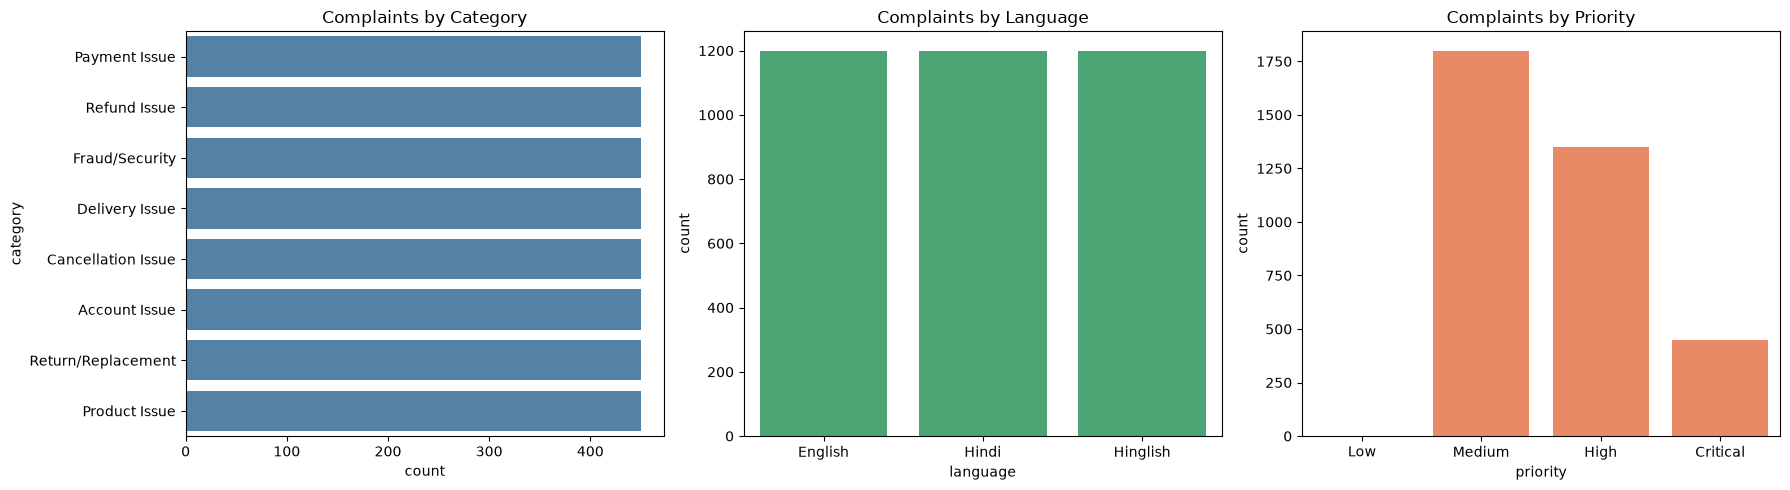

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(
    data=full_df,
    y="category",
    order=full_df["category"].value_counts().index,
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Complaints by Category")

sns.countplot(
    data=full_df,
    x="language",
    order=LANGUAGES,
    ax=axes[1],
    color="mediumseagreen"
)
axes[1].set_title("Complaints by Language")

sns.countplot(
    data=full_df,
    x="priority",
    order=["Low", "Medium", "High", "Critical"],
    ax=axes[2],
    color="coral"
)
axes[2].set_title("Complaints by Priority")

plt.tight_layout()
plt.show()